In [1]:
# notebook to check how ChIP binding tracks with distal element activity

In [42]:
# import packages
import pandas as pd
import numpy as np
import pybedtools
import seaborn as sns
import matplotlib.pyplot as plt
import os
import requests
from collections import Counter
from scipy import stats

In [2]:
# open BED files
# ENCODE dELS - cell type agnostic
dELS_bed = pybedtools.BedTool('../processed_data/GRCh38-dELS-only.bed')
# ENCODE cCRE - K562
k562_cCRE = pybedtools.BedTool('../raw_data/ENCFF414OGC_ENCFF806YEZ_ENCFF849TDM_ENCFF736UDR_K562_cCRE.bed')
# ENCODE cCRE - HepG2
hepg2_cCRE = pybedtools.BedTool('../raw_data/ENCFF546MZK_ENCFF732PJK_ENCFF795ONN_ENCFF357NFO_HepG2_cCRE.bed')
# ENCODE cCRE - SKNSH
sknsh_cCRE = pybedtools.BedTool('../raw_data/ENCFF280RMA_ENCFF651WOM_ENCFF262UEH_ENCFF850MLW_SKNSH_cCRE.bed')
# ChIP #
# K562 GATA2
k562_gata2_bed = pybedtools.BedTool('../raw_data/ChIP_BEDs/ENCFF772OKO.bed.gz').sort()
# HepG2 HNF1B 
hepg2_hnf1b_bed = pybedtools.BedTool('../raw_data/ChIP_BEDs/ENCFF022QCK.bed.gz').sort()
# SKNSH IRF3
sknsh_irf3_bed = pybedtools.BedTool('../raw_data/ChIP_BEDs/ENCFF865YQH.bed.gz').sort()

In [3]:
# open enhancer level averaged predictions #
all_mean_preds = pd.read_csv('../processed_data/all_dELS_sat_mut_groupby_mean.tsv',
                             sep = '\t')

In [4]:
all_mean_preds[all_mean_preds['id'] == 'EH38E2776794']

,id,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,hepg2_skew_pred,sknsh_ref_pred,sknsh_alt_pred,sknsh_skew_pred
44950,EH38E2776794,0.45344,0.477054,0.023613,0.565694,0.579649,0.013955,0.345778,0.361647,0.015868


In [5]:
# get intersection of TF BED files and dELS/cCREs to get IDs for comparing activity
# K562 GATA agnostic
k_gata_dELS_agnostic = dELS_bed.intersect(k562_gata2_bed, wa=True).to_dataframe()#['score'].tolist() #### 'score' contains Enhancer ID
# K562 GATA cellMatched
k_gata_cCRE_matched = k562_cCRE.intersect(k562_gata2_bed, wa=True).to_dataframe() #### 'name' Enhancer ID, 'blockCount' includes cCRE class ie dELS, CA-TF, etc.
# HepG2 HNF1B agnostic
h_hnf1b_dELS_agnostic = dELS_bed.intersect(hepg2_hnf1b_bed, wa=True).to_dataframe()
# HepG2 HNF1B cellMatched
h_hnf1b_cCRE_matched = hepg2_cCRE.intersect(hepg2_hnf1b_bed, wa=True).to_dataframe()
# SKNSH IRF3 agnostic
s_irf3_dELS_agnostic = dELS_bed.intersect(sknsh_irf3_bed, wa=True).to_dataframe()
# SKNSH IRF3 cellMatched
s_irf3_cCRE_matched = sknsh_cCRE.intersect(sknsh_irf3_bed, wa=True).to_dataframe()

In [6]:
# define a function for returning a dictionary of Enhancer IDs : agnostic cCREs
def return_agnostic_dict (agnostic_bed):
    dict2return = dict(zip(
        agnostic_bed['score'], # Enhancer ID name
        [1 for i in range(len(agnostic_bed))] # score of hit
    ))
    return dict2return
# define a function for returning a dictionary of Enhancer IDs : matched cCREs (want to filter for only dELS here)
def return_matched_dict (matched_bed):
    # filter the intersection for only those in dELS
    dELS_intersect = matched_bed[matched_bed['blockCount'] == 'dELS']
    # now build the dictionary from the filtered intersection
    dict2return = dict(zip(
        dELS_intersect['name'],
        [1 for i in range(len(dELS_intersect))]
    ))
    return dict2return
# define a function for returning a list for adding annotations to predictions DF
def return_bound_list (preds_df, tf_dict):
    return [tf_dict.get(i) if i in tf_dict.keys() else 0 for i in preds_df['id']]

In [7]:
# make dictionaries for adding annotations to predictions
# k562
k_gata_dels_agnostic_dict = return_agnostic_dict(k_gata_dELS_agnostic)
k_gata_cCRE_matched_dict = return_matched_dict(k_gata_cCRE_matched)
# hepg2
h_hnf1b_dELS_agnostic_dict = return_agnostic_dict(h_hnf1b_dELS_agnostic)
h_hnf1b_cCRE_matched_dict = return_matched_dict(h_hnf1b_cCRE_matched)
# sknsh
s_irf3_dels_agnostic_dict = return_agnostic_dict(s_irf3_dELS_agnostic)
s_irf3_cCRE_matched_dict = return_matched_dict(s_irf3_cCRE_matched)

In [8]:
# add TF annotations to mean ref preds
# k562 gata agnostic cCREs
all_mean_preds.loc[:, 'k_gata_agnostic'] = return_bound_list(all_mean_preds, k_gata_dels_agnostic_dict)
# k562 gata matched cCREs
all_mean_preds.loc[:, 'k_gata_matched'] = return_bound_list(all_mean_preds, k_gata_cCRE_matched_dict)
# make an annotated column for plotting the three together
all_mean_preds.loc[:, 'k_gata_ann'] = ['K562 dELS Bound' if matched == 1 else 'Agnostic dELS Bound' if agnostic == 1 and matched == 0 else 'Not Bound' for matched, agnostic in zip(all_mean_preds['k_gata_matched'], all_mean_preds['k_gata_agnostic'])]
# hepg2 hnf1b agnostic cCREs
all_mean_preds.loc[:, 'h_hnf1b_agnostic'] = [h_hnf1b_dELS_agnostic_dict.get(i) if i in h_hnf1b_dELS_agnostic_dict.keys() else 0 for i in all_mean_preds['id']]
# hepg2 hnf1b matched cCREs
all_mean_preds.loc[:, 'h_hnf1b_matched'] = [h_hnf1b_cCRE_matched_dict.get(i) if i in h_hnf1b_cCRE_matched_dict.keys() else 0 for i in all_mean_preds['id']]
# make an annotated column for plotting the three together
all_mean_preds.loc[:, 'h_hnf1b_ann'] = ['HepG2 dELS Bound' if matched == 1 else 'Agnostic dELS Bound' if agnostic == 1 and matched == 0 else 'Not Bound' for matched, agnostic in zip(all_mean_preds['h_hnf1b_matched'], all_mean_preds['h_hnf1b_agnostic'])]
# sknsh irf3 agnostic cCREs
all_mean_preds.loc[:, 's_irf3_agnostic'] = return_bound_list(all_mean_preds, s_irf3_dels_agnostic_dict)
# sknsh irf3 matched cCREs
all_mean_preds.loc[:, 's_irf3_matched'] = return_bound_list(all_mean_preds, s_irf3_cCRE_matched_dict)
# make an annotated column for plotting the three together
all_mean_preds.loc[:, 's_irf3_ann'] = ['SKNSH dELS Bound' if matched == 1 else 'Agnostic dELS Bound' if agnostic == 1 and matched == 0 else 'Not Bound' for matched, agnostic in zip(all_mean_preds['s_irf3_matched'], all_mean_preds['s_irf3_agnostic'])]

In [56]:
# make a dictionary for coloring plot
colorPal = {
    'K562 dELS Bound' : '#00A79D',
    'HepG2 dELS Bound' : '#FBB040',
    'SKNSH dELS Bound' : '#ED1C24',
    'Agnostic dELS Bound' : 'powderblue',
    'Not Bound' : 'gray'
}
colorPal_k_h = {
    'K562 dELS Bound' : '#FBB040',
    'HepG2 dELS Bound' : '#FBB040',
    'SKNSH dELS Bound' : '#ED1C24',
    'Agnostic dELS Bound' : 'powderblue',
    'Not Bound' : 'gray'
}
colorPal_k_s = {
    'K562 dELS Bound' : '#ED1C24',
    'HepG2 dELS Bound' : '#FBB040',
    'SKNSH dELS Bound' : '#ED1C24',
    'Agnostic dELS Bound' : 'powderblue',
    'Not Bound' : 'gray'
}

colorPal_h_k = {
    'K562 dELS Bound' : '#00A79D',
    'HepG2 dELS Bound' : '#00A79D',
    'SKNSH dELS Bound' : '#ED1C24',
    'Agnostic dELS Bound' : 'powderblue',
    'Not Bound' : 'gray'
}
colorPal_h_s = {
    'K562 dELS Bound' : '#ED1C24',
    'HepG2 dELS Bound' : '#ED1C24',
    'SKNSH dELS Bound' : '#ED1C24',
    'Agnostic dELS Bound' : 'powderblue',
    'Not Bound' : 'gray'
}

colorPal_s_k = {
    'K562 dELS Bound' : '#00A79D',
    'HepG2 dELS Bound' : '#00A79D',
    'SKNSH dELS Bound' : '#00A79D',
    'Agnostic dELS Bound' : 'powderblue',
    'Not Bound' : 'gray'
}
colorPal_s_h = {
    'K562 dELS Bound' : '#ED1C24',
    'HepG2 dELS Bound' : '#ED1C24',
    'SKNSH dELS Bound' : '#FBB040',
    'Agnostic dELS Bound' : 'powderblue',
    'Not Bound' : 'gray'
}

In [10]:
#all_mean_preds.sort_values(by=['s_irf3_ann'], key=lambda x: x.map(custom_dict))
k_order_dict = {'Not Bound' : 0, 'Agnostic dELS Bound' : 1, 'K562 dELS Bound' : 2}
h_order_dict = {'Not Bound' : 0, 'Agnostic dELS Bound' : 1, 'HepG2 dELS Bound' : 2}
s_order_dict = {'Not Bound' : 0, 'Agnostic dELS Bound' : 1, 'SKNSH dELS Bound' : 2}

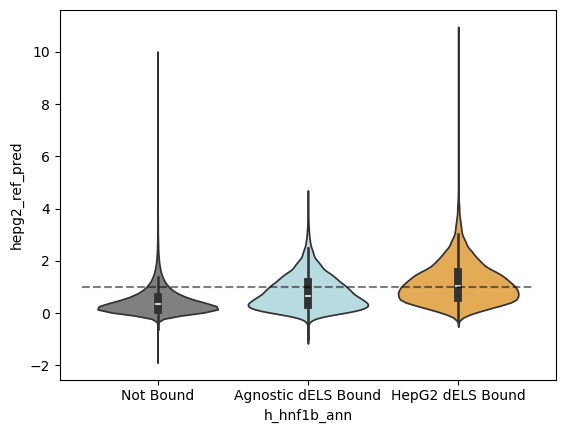

In [37]:
sns.violinplot(
    data=all_mean_preds.sort_values(by=['h_hnf1b_ann'], key=lambda x: x.map(h_order_dict)),
    x='h_hnf1b_ann',
    y='hepg2_ref_pred',
    hue='h_hnf1b_ann',
    palette=colorPal
)
plt.hlines(y=1, xmin=-0.5, xmax=2.5, linestyles='dashed', color='k', alpha=0.5)

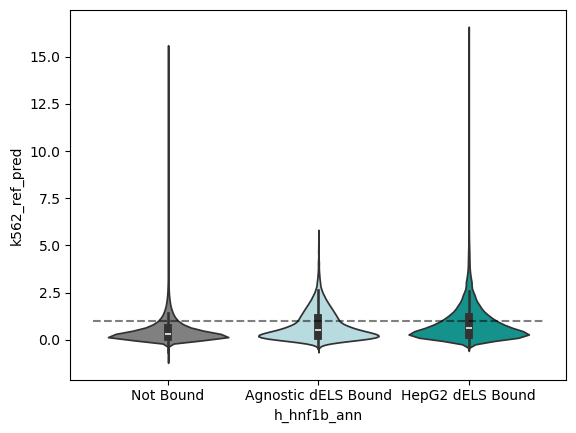

In [52]:
sns.violinplot(
    data=all_mean_preds.sort_values(by=['h_hnf1b_ann'], key=lambda x: x.map(h_order_dict)),
    x='h_hnf1b_ann',
    y='k562_ref_pred',
    hue='h_hnf1b_ann',
    palette=colorPal_h_k
)
plt.hlines(y=1, xmin=-0.5, xmax=2.5, linestyles='dashed', color='k', alpha=0.5)

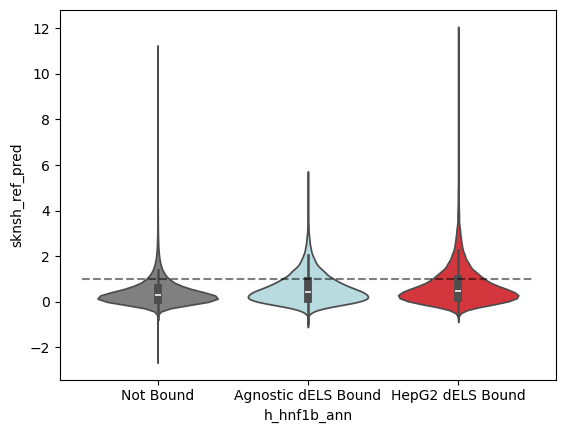

In [55]:
sns.violinplot(
    data=all_mean_preds.sort_values(by=['h_hnf1b_ann'], key=lambda x: x.map(h_order_dict)),
    x='h_hnf1b_ann',
    y='sknsh_ref_pred',
    hue='h_hnf1b_ann',
    palette=colorPal_h_s
)
plt.hlines(y=1, xmin=-0.5, xmax=2.5, linestyles='dashed', color='k', alpha=0.5)

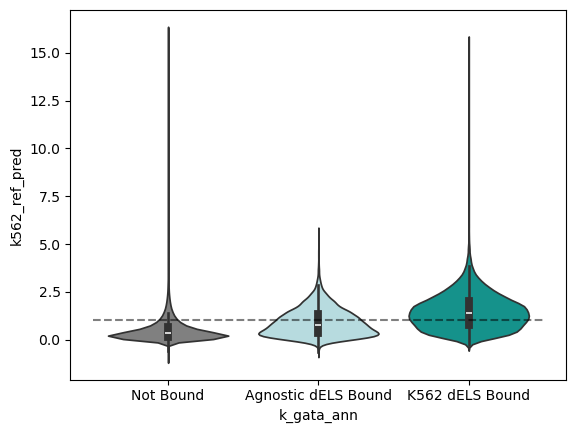

In [38]:
sns.violinplot(
    data=all_mean_preds.sort_values(by=['k_gata_ann'], key=lambda x: x.map(k_order_dict)),
    x='k_gata_ann',
    y='k562_ref_pred',
    hue='k_gata_ann',
    palette=colorPal
)
plt.hlines(y=1, xmin=-0.5, xmax=2.5, linestyles='dashed', color='k', alpha=0.5)

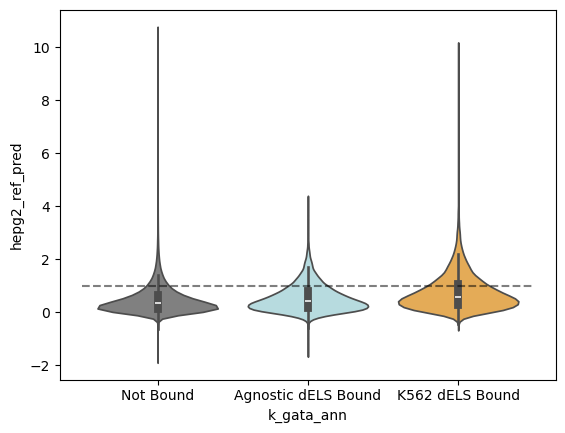

In [47]:
sns.violinplot(
    data=all_mean_preds.sort_values(by=['k_gata_ann'], key=lambda x: x.map(k_order_dict)),
    x='k_gata_ann',
    y='hepg2_ref_pred',
    hue='k_gata_ann',
    palette=colorPal_k_h
)
plt.hlines(y=1, xmin=-0.5, xmax=2.5, linestyles='dashed', color='k', alpha=0.5)

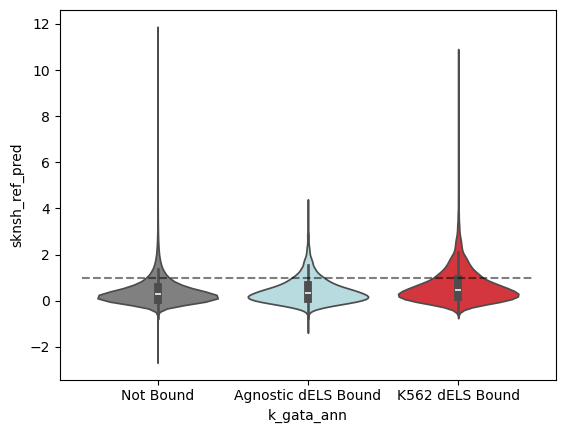

In [50]:
sns.violinplot(
    data=all_mean_preds.sort_values(by=['k_gata_ann'], key=lambda x: x.map(k_order_dict)),
    x='k_gata_ann',
    y='sknsh_ref_pred',
    hue='k_gata_ann',
    palette=colorPal_k_s
)
plt.hlines(y=1, xmin=-0.5, xmax=2.5, linestyles='dashed', color='k', alpha=0.5)

In [43]:
# Assuming you have your data in groups
not_bound = all_mean_preds[all_mean_preds['k_gata_ann'] == 'Not Bound']['k562_ref_pred']
agnostic = all_mean_preds[all_mean_preds['k_gata_ann'] == 'Agnostic dELS Bound']['k562_ref_pred']
k562 = all_mean_preds[all_mean_preds['k_gata_ann'] == 'K562 dELS Bound']['k562_ref_pred']

# One-way ANOVA
f_stat, p_value = stats.f_oneway(not_bound, agnostic, k562)
print(f"ANOVA F-statistic: {f_stat}, p-value: {p_value}")

ANOVA F-statistic: 13242.207902938677, p-value: 0.0


In [13]:
gata_seqlets = pybedtools.BedTool('../processed_data/all_k562_gata_seqlets_check.bed').sort()

In [14]:
len(gata_seqlets)

38758

In [28]:
gata_seqlet_chip_intersect = gata_seqlets.intersect(k562_gata2_bed, wa=True)
gata_peaks_w_seqlet = k562_gata2_bed.intersect(gata_seqlets, wa=True).to_dataframe()
gata_peaks_no_seqlet = k562_gata2_bed.intersect(gata_seqlets, v=True).to_dataframe()

In [31]:
gata_peaks_w_seqlet.loc[:, 'seqlet'] = [1 for i in range(len(gata_peaks_w_seqlet))]
gata_peaks_no_seqlet.loc[:, 'seqlet'] = [0 for i in range(len(gata_peaks_no_seqlet))]
gata_seqlet_ann = pd.concat([gata_peaks_w_seqlet, gata_peaks_no_seqlet]).drop_duplicates()

<Axes: xlabel='seqlet', ylabel='thickStart'>

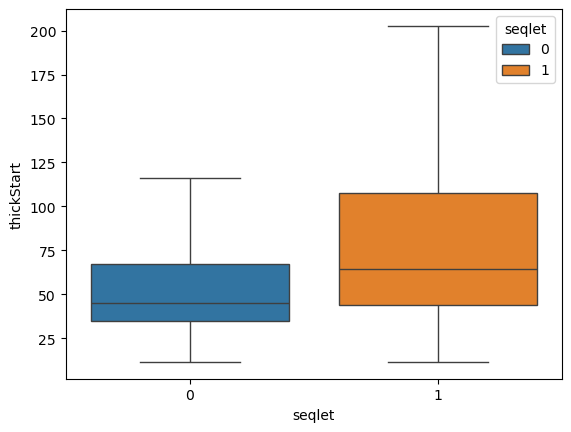

In [36]:
sns.boxplot(
    data = gata_seqlet_ann,
    x='seqlet',
    y='thickStart',
    showfliers=False,
    hue='seqlet'
)

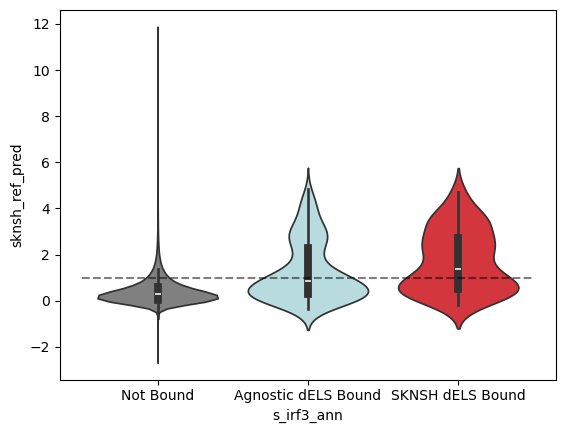

In [48]:
sns.violinplot(
    data=all_mean_preds.sort_values(by=['s_irf3_ann'], key=lambda x: x.map(s_order_dict)),
    x='s_irf3_ann',
    y='sknsh_ref_pred',
    hue='s_irf3_ann',
    palette=colorPal
)
plt.hlines(y=1, xmin=-0.5, xmax=2.5, linestyles='dashed', color='k', alpha=0.5)

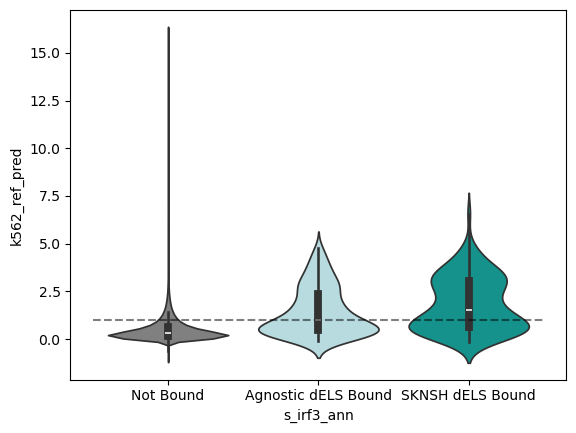

In [57]:
sns.violinplot(
    data=all_mean_preds.sort_values(by=['s_irf3_ann'], key=lambda x: x.map(s_order_dict)),
    x='s_irf3_ann',
    y='k562_ref_pred',
    hue='s_irf3_ann',
    palette=colorPal_s_k
)
plt.hlines(y=1, xmin=-0.5, xmax=2.5, linestyles='dashed', color='k', alpha=0.5)

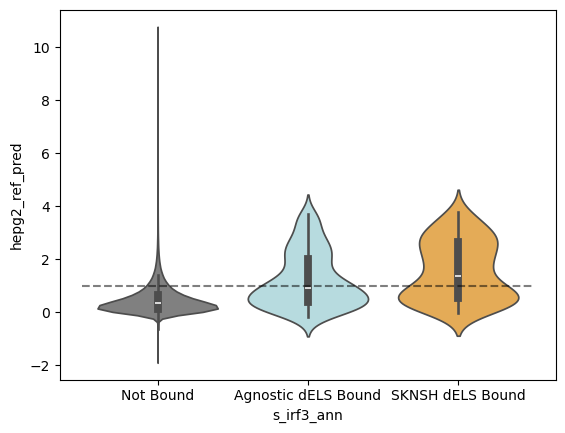

In [58]:
sns.violinplot(
    data=all_mean_preds.sort_values(by=['s_irf3_ann'], key=lambda x: x.map(s_order_dict)),
    x='s_irf3_ann',
    y='hepg2_ref_pred',
    hue='s_irf3_ann',
    palette=colorPal_s_h
)
plt.hlines(y=1, xmin=-0.5, xmax=2.5, linestyles='dashed', color='k', alpha=0.5)

In [17]:
# # define function for getting all ChIP seq targets
# def get_all_tf_targets():
#     """Get complete list of all TF targets in ENCODE ChIP-seq"""
    
#     params = {
#         'type': 'Target',
#         'investigated_as': 'transcription factor',
#         'format': 'json',
#         'limit': 'all'
#     }
    
#     response = requests.get('https://www.encodeproject.org/search/', params=params)
#     targets = response.json()['@graph']
    
#     # Extract target labels
#     target_labels = sorted([t['label'] for t in targets])
    
#     return target_labels, targets
# def find_tf_family_members(family_prefix):
#     """Find all TFs matching a family name pattern"""
    
#     all_targets, _ = get_all_tf_targets()
    
#     # Case-insensitive pattern matching
#     family_members = [
#         target for target in all_targets 
#         if target.upper().startswith(family_prefix.upper())
#     ]
    
#     return family_members

In [ ]:
# # define function for querying chip experiments programmatically
# def download_chip_peaks(cell_type, target, output_dir='../raw_data/ChIP_BEDs/'):
#     """Download optimal IDR peak files for a TF in a cell type"""
    
#     os.makedirs(output_dir, exist_ok=True)
    
#     params = {
#         'type': 'Experiment',
#         'assay_title': 'TF ChIP-seq',
#         'biosample_ontology.term_name': cell_type,
#         'target.label': target,
#         'status': 'released',
#         'format': 'json',
#         'frame': 'embedded',
#         'limit': 'all',
#     }
    
#     response = requests.get('https://www.encodeproject.org/search/', params=params)
#     experiments = response.json()['@graph']
    
#     for exp in experiments:
#         for file_obj in exp.get('files', []):
#             # Get optimal IDR thresholded peaks
#             if (file_obj['file_format'] == 'bed' and
#                 file_obj['output_type'] == 'IDR thresholded peaks'):
                
#                 acc = file_obj['accession']
#                 url = 'https://www.encodeproject.org' + file_obj['href']
                
#                 filename = f"{exp['accession']}_{target}_{cell_type}_{acc}.bed.gz"
#                 filepath = os.path.join(output_dir, filename)
                
#                 print(f"Downloading {filename}")
#                 r = requests.get(url)
#                 with open(filepath, 'wb') as f:
#                     f.write(r.content)